<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Lab5_1_time_series_Peru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Series de Tiempo
## Ciencia de Datos Ambientales – Aplicado al Perú

**Duración:** 75 minutos

**Objetivos de aprendizaje:**
- Trabajar con objetos datetime en pandas
- Indexar y segmentar series de tiempo por fecha
- Remuestrear datos a diferentes frecuencias temporales
- Aplicar ventanas deslizantes para suavizado
- Descomponer series de tiempo en tendencia, estacionalidad y residuos
- Comprender la autocorrelación y la estacionariedad
- Aplicar métodos simples de pronóstico

---

In [ ]:
# Importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para descomposición de series de tiempo
from statsmodels.tsa.seasonal import seasonal_decompose

---
## 1. Introducción a las Series de Tiempo

Una **serie de tiempo** es una secuencia de datos recopilados a lo largo del tiempo. Ejemplos ambientales peruanos:

- Temperatura y precipitación diaria (SENAMHI)
- Caudal mensual de ríos (ANA – Autoridad Nacional del Agua)
- Mediciones de calidad del aire en Lima
- Nivel del Lago Titicaca a lo largo del tiempo (INAIGEM)
- Índice de deforestación anual en la Amazonia (MINAM/MAAP)

**Características clave de las series de tiempo:**
- **Tendencia:** Aumento o disminución a largo plazo
- **Estacionalidad:** Patrones regulares que se repiten (diario, anual, etc.)
- **Ruido:** Variación aleatoria

In [ ]:
# Crear serie de tiempo ambiental: precipitación y temperatura en Iquitos (2020–2024)
# Basada en el patrón climático real de la Amazonia peruana – datos tipo SENAMHI
np.random.seed(42)

fechas       = pd.date_range('2020-01-01', '2024-12-31', freq='D')
n_dias       = len(fechas)
dia_del_anio = fechas.dayofyear

# Componentes de temperatura (Iquitos tiene poca variación estacional, ~28°C)
estacional_temp = 2.5 * np.sin(2 * np.pi * (dia_del_anio - 30) / 365)  # Amplitud pequeña
tendencia_temp  = np.linspace(0, 1.2, n_dias)                           # Calentamiento gradual
ruido_temp      = np.random.normal(0, 1.5, n_dias)
temperatura     = 28 + estacional_temp + tendencia_temp + ruido_temp

# Precipitación: alta en época de lluvias (Dic–Mar), baja en vaciante (Jun–Sep)
estacional_prec = 8 + 6 * np.sin(2 * np.pi * (dia_del_anio - 20) / 365)
precipitacion   = np.maximum(
    estacional_prec * np.random.exponential(1.0, n_dias), 0
)

clima = pd.DataFrame({
    'fecha'          : fechas,
    'temperatura_c'  : temperatura,
    'precipitacion_mm': precipitacion,
})

print(f"Dataset: {len(clima)} días desde {clima['fecha'].min().date()} hasta {clima['fecha'].max().date()}")
clima.head()

Dataset: 1827 días desde 2020-01-01 hasta 2024-12-31


,fecha,temperatura_c,precipitacion_mm
0,2020-01-01,27.548237,5.468587
1,2020-01-02,26.634385,0.062833
2,2020-01-03,27.852274,6.337221
3,2020-01-04,29.204577,15.571335
4,2020-01-05,26.608415,6.133032


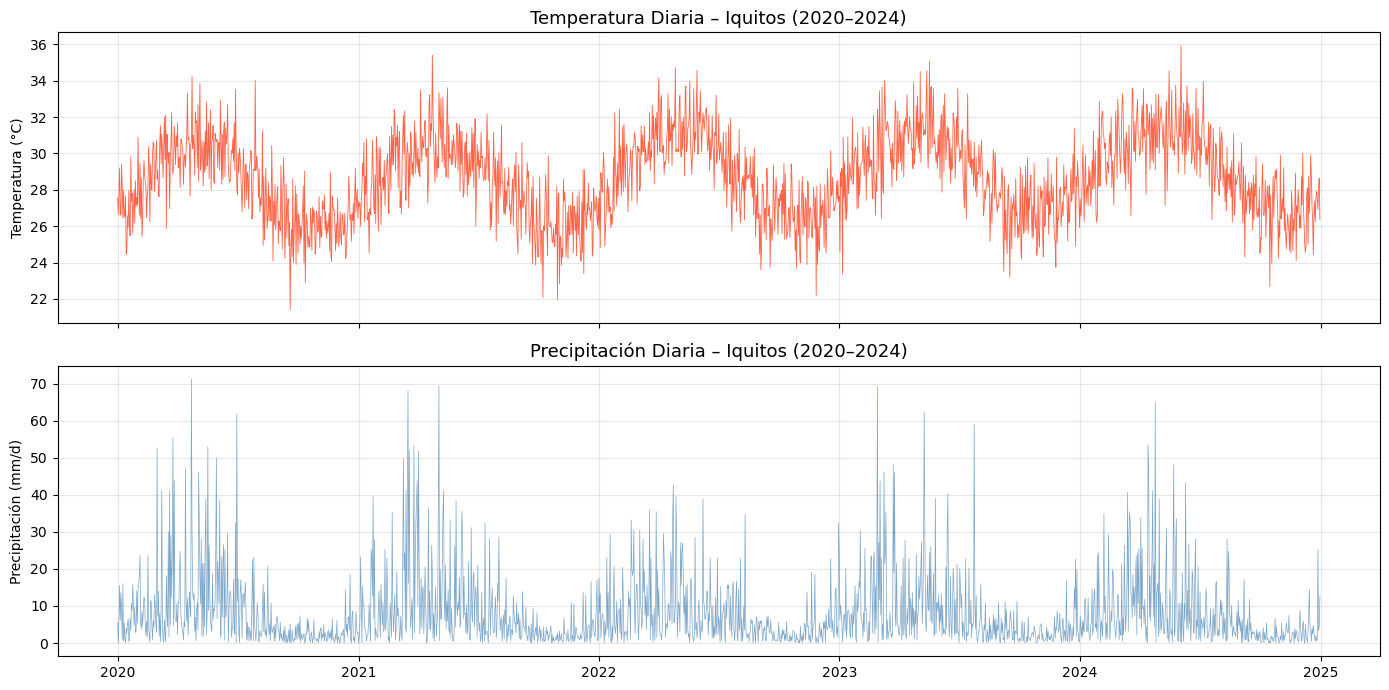

In [ ]:
# Visualización rápida
fig, ejes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ejes[0].plot(clima['fecha'], clima['temperatura_c'], linewidth=0.6, color='tomato')
ejes[0].set_ylabel('Temperatura (°C)')
ejes[0].set_title('Temperatura Diaria – Iquitos (2020–2024)', fontsize=13)
ejes[0].grid(True, alpha=0.3)

ejes[1].plot(clima['fecha'], clima['precipitacion_mm'], linewidth=0.5, color='steelblue', alpha=0.7)
ejes[1].set_ylabel('Precipitación (mm/d)')
ejes[1].set_title('Precipitación Diaria – Iquitos (2020–2024)', fontsize=13)
ejes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Trabajar con DateTime en Pandas

### 2.1 Tipos de datos DateTime

In [ ]:
# Verificar el tipo de dato de la columna de fecha
print(f"Tipo de columna fecha: {clima['fecha'].dtype}")

Tipo de columna fecha: datetime64[ns]


In [ ]:
# Si las fechas están como cadenas, convertir con pd.to_datetime()
fechas_cadena = ['2024-01-15', '2024-02-20', '2024-03-25']
print(f"Tipo original: {type(fechas_cadena[0])}")

fechas_convertidas = pd.to_datetime(fechas_cadena)
print(f"Tipo convertido: {fechas_convertidas.dtype}")
print(fechas_convertidas)

Tipo original: <class 'str'>
Tipo convertido: datetime64[ns]
DatetimeIndex(['2024-01-15', '2024-02-20', '2024-03-25'], dtype='datetime64[ns]', freq=None)


In [ ]:
# pd.to_datetime() acepta muchos formatos
print(pd.to_datetime('2024-01-15'))        # Formato ISO
print(pd.to_datetime('15/01/2024'))        # Formato europeo
print(pd.to_datetime('15-Jan-2024'))       # Con nombre de mes abreviado
print(pd.to_datetime('january 15, 2024'))    # Nombre completo (puede variar según locale)

2024-01-15 00:00:00
2024-01-15 00:00:00
2024-01-15 00:00:00
2024-01-15 00:00:00


C:\Users\cmillan\AppData\Local\Temp\ipykernel_67880\602710164.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  print(pd.to_datetime('15/01/2024'))        # Formato europeo


### 2.2 Extraer componentes de fecha

Usa el accesor `.dt` para extraer partes de un datetime.

In [ ]:
# Extraer varios componentes temporales
clima['anio']         = clima['fecha'].dt.year
clima['mes']          = clima['fecha'].dt.month
clima['dia']          = clima['fecha'].dt.day
clima['dia_del_anio'] = clima['fecha'].dt.dayofyear
clima['dia_semana']   = clima['fecha'].dt.dayofweek   # 0=Lunes, 6=Domingo
clima['semana']       = clima['fecha'].dt.isocalendar().week
clima['trimestre']    = clima['fecha'].dt.quarter

clima[['fecha', 'anio', 'mes', 'dia', 'dia_del_anio', 'dia_semana', 'trimestre']].head(10)

,fecha,anio,mes,dia,dia_del_anio,dia_semana,trimestre
0,2020-01-01,2020,1,1,1,2,1
1,2020-01-02,2020,1,2,2,3,1
2,2020-01-03,2020,1,3,3,4,1
3,2020-01-04,2020,1,4,4,5,1
4,2020-01-05,2020,1,5,5,6,1
5,2020-01-06,2020,1,6,6,0,1
6,2020-01-07,2020,1,7,7,1,1
7,2020-01-08,2020,1,8,8,2,1
8,2020-01-09,2020,1,9,9,3,1
9,2020-01-10,2020,1,10,10,4,1


In [ ]:
# Obtener nombres de mes
clima['nombre_mes'] = clima['fecha'].dt.month_name()
clima[['fecha', 'mes', 'nombre_mes']].drop_duplicates('mes').head(12)

,fecha,mes,nombre_mes
0,2020-01-01,1,January
31,2020-02-01,2,February
60,2020-03-01,3,March
91,2020-04-01,4,April
121,2020-05-01,5,May
152,2020-06-01,6,June
182,2020-07-01,7,July
213,2020-08-01,8,August
244,2020-09-01,9,September
274,2020-10-01,10,October


### 2.3 Establecer DateTime como índice

Establecer la fecha como índice habilita operaciones potentes sobre series de tiempo.

In [ ]:
# Establecer fecha como índice
clima_ts = clima.set_index('fecha')
clima_ts.head()

,temperatura_c,precipitacion_mm,anio,mes,dia,dia_del_anio,dia_semana,semana,trimestre,nombre_mes
fecha,,,,,,,,,,
2020-01-01,27.548237,5.468587,2020,1,1,1,2,1,1,January
2020-01-02,26.634385,0.062833,2020,1,2,2,3,1,1,January
2020-01-03,27.852274,6.337221,2020,1,3,3,4,1,1,January
2020-01-04,29.204577,15.571335,2020,1,4,4,5,1,1,January
2020-01-05,26.608415,6.133032,2020,1,5,5,6,1,1,January


In [ ]:
# Verificar el tipo de índice
print(f"Tipo de índice: {type(clima_ts.index)}")
print(f"Dtype del índice: {clima_ts.index.dtype}")

Tipo de índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Dtype del índice: datetime64[ns]


---
## 3. Indexado y Segmentado por Fecha

Con un DatetimeIndex puedes seleccionar datos usando cadenas de fecha.

### 3.1 Seleccionar fechas específicas

In [ ]:
# Seleccionar una fecha específica – 28 de julio de 2022 (Día de la Independencia del Perú)
clima_ts.loc['2022-07-28']

temperatura_c       27.921502
precipitacion_mm     11.92807
anio                     2022
mes                         7
dia                        28
dia_del_anio              209
dia_semana                  3
semana                     30
trimestre                   3
nombre_mes               July
Name: 2022-07-28 00:00:00, dtype: object

In [ ]:
# Seleccionar un mes específico (indexado parcial por cadena)
marzo_2023 = clima_ts.loc['2023-03']
print(f"Marzo 2023: {len(marzo_2023)} días")
marzo_2023.head()

Marzo 2023: 31 días


,temperatura_c,precipitacion_mm,anio,mes,dia,dia_del_anio,dia_semana,semana,trimestre,nombre_mes
fecha,,,,,,,,,,
2023-03-01,31.508201,0.360119,2023,3,1,60,2,9,1,March
2023-03-02,28.999145,27.072639,2023,3,2,61,3,9,1,March
2023-03-03,33.447543,11.664943,2023,3,3,62,4,9,1,March
2023-03-04,31.578669,43.683495,2023,3,4,63,5,9,1,March
2023-03-05,29.655506,7.582586,2023,3,5,64,6,9,1,March


In [ ]:
# Seleccionar un año entero
anio_2021 = clima_ts.loc['2021']
print(f"Año 2021: {len(anio_2021)} días")
anio_2021.head()

Año 2021: 365 días


,temperatura_c,precipitacion_mm,anio,mes,dia,dia_del_anio,dia_semana,semana,trimestre,nombre_mes
fecha,,,,,,,,,,
2021-01-01,27.379830,0.008225,2021,1,1,1,4,53,1,January
2021-01-02,27.101196,2.199095,2021,1,2,2,5,53,1,January
2021-01-03,27.267781,6.518334,2021,1,3,3,6,53,1,January
2021-01-04,26.001044,23.289748,2021,1,4,4,0,1,1,January
2021-01-05,27.236936,12.144836,2021,1,5,5,1,1,1,January


### 3.2 Seleccionar rangos de fechas

In [ ]:
# Seleccionar un rango de fechas – época de lluvias 2023 (Dic 2022 – Mar 2023)
epocas_lluvias = clima_ts.loc['2022-12-01':'2023-03-31']
print(f"Época de lluvias 2022-2023: {len(epocas_lluvias)} días")
print(f"Precipitación media: {epocas_lluvias['precipitacion_mm'].mean():.1f} mm/día")

Época de lluvias 2022-2023: 121 días
Precipitación media: 10.1 mm/día


In [ ]:
# Seleccionar desde una fecha hasta el final
reciente = clima_ts.loc['2024-10-01':]
print(f"Desde Oct 2024 al final: {len(reciente)} días")

Desde Oct 2024 al final: 92 días


In [ ]:
# Seleccionar hasta una fecha
inicio = clima_ts.loc[:'2020-03-31']
print(f"Hasta marzo 2020: {len(inicio)} días")

Hasta marzo 2020: 91 días


### 3.3 Filtrar con condiciones booleanas

In [ ]:
# Obtener todos los días de enero en todos los años
# (mes más lluvioso en la Amazonia peruana)
todos_eneros = clima_ts[clima_ts.index.month == 1]
print(f"Días de enero (todos los años): {len(todos_eneros)}")
print(f"Precipitación media en enero: {todos_eneros['precipitacion_mm'].mean():.1f} mm/día")

Días de enero (todos los años): 155
Precipitación media en enero: 7.5 mm/día


In [ ]:
# Obtener los meses de vaciante (junio–septiembre) en toda la serie
vaciante = clima_ts[clima_ts.index.month.isin([6, 7, 8, 9])]
print(f"Días de vaciante (Jun–Sep, todos los años): {len(vaciante)}")
print(f"Precipitación media en vaciante: {vaciante['precipitacion_mm'].mean():.1f} mm/día")

Días de vaciante (Jun–Sep, todos los años): 610
Precipitación media en vaciante: 6.8 mm/día


### 🔬 Ejercicio rápido 1 – Indexado temporal

Usando `clima_ts`:

1. Selecciona todos los datos del año **2022** y calcula la temperatura media
2. Selecciona el período de **vaciante del río Ucayali** (1 jun – 30 sep 2023) y calcula la precipitación total
3. ¿Cuántos días de toda la serie tuvieron precipitación superior a **20 mm** (día lluvioso intenso)?

In [ ]:
# Tu código aquí

# datos_2022 = clima_ts.loc[???]
# temp_media_2022 = ???

# vaciante_2023 = clima_ts.loc[???]
# precip_total_vaciante = ???

# dias_lluviosos = len(clima_ts[???])

---
## 4. Remuestreo

**Remuestrear** cambia la frecuencia de tu serie de tiempo:
- **Downsample:** Mayor a menor frecuencia (diario → mensual)
- **Upsample:** Menor a mayor frecuencia (mensual → diario)

### 4.1 Códigos de frecuencia comunes

| Código | Frecuencia |
|--------|------------|
| `D` | Diario |
| `W` | Semanal |
| `M` | Fin de mes |
| `MS` | Inicio de mes |
| `Q` | Fin de trimestre |
| `Y` | Fin de año |
| `H` | Por hora |

In [ ]:
# Remuestrear datos diarios a medias mensuales de temperatura
mensual = clima_ts['temperatura_c'].resample('M').mean()

print(f"Original: {len(clima_ts)} observaciones diarias")
print(f"Remuestreado: {len(mensual)} observaciones mensuales")
mensual.head(12)

Original: 1827 observaciones diarias
Remuestreado: 60 observaciones mensuales


C:\Users\cmillan\AppData\Local\Temp\ipykernel_67880\270199783.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mensual = clima_ts['temperatura_c'].resample('M').mean()


fecha
2020-01-31    27.117992
2020-02-29    28.545551
2020-03-31    29.830817
2020-04-30    30.466726
2020-05-31    30.322369
2020-06-30    30.215478
2020-07-31    28.974872
2020-08-31    27.420959
2020-09-30    26.201402
2020-10-31    25.884320
2020-11-30    26.238346
2020-12-31    26.386201
Freq: ME, Name: temperatura_c, dtype: float64

In [ ]:
# Diferentes funciones de agregación
stats_mensuales = clima_ts['temperatura_c'].resample('M').agg(['mean', 'min', 'max', 'std'])
stats_mensuales.head(12)

C:\Users\cmillan\AppData\Local\Temp\ipykernel_67880\3305774903.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stats_mensuales = clima_ts['temperatura_c'].resample('M').agg(['mean', 'min', 'max', 'std'])


,mean,min,max,std
fecha,,,,
2020-01-31,27.117992,24.458728,29.825845,1.251606
2020-02-29,28.545551,25.428007,30.884844,1.500617
2020-03-31,29.830817,25.867659,32.248093,1.494785
2020-04-30,30.466726,27.655317,34.249679,1.408892
2020-05-31,30.322369,28.008904,33.859477,1.496360
2020-06-30,30.215478,28.086317,33.524713,1.446088
2020-07-31,28.974872,26.389430,34.024002,1.459480
2020-08-31,27.420959,24.093989,31.252068,1.541451
2020-09-30,26.201402,21.400557,29.743705,1.853386


In [ ]:
# Para precipitación, la suma es más apropiada que la media
precip_mensual = clima_ts['precipitacion_mm'].resample('M').sum()
print("Precipitación mensual acumulada (mm):")
precip_mensual.head(12)

Precipitación mensual acumulada (mm):


C:\Users\cmillan\AppData\Local\Temp\ipykernel_67880\2081365907.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  precip_mensual = clima_ts['precipitacion_mm'].resample('M').sum()


fecha
2020-01-31    194.741023
2020-02-29    244.113799
2020-03-31    456.200750
2020-04-30    376.970523
2020-05-31    528.512072
2020-06-30    428.972834
2020-07-31    253.483341
2020-08-31    159.180607
2020-09-30     61.210223
2020-10-31     68.120561
2020-11-30     63.731045
2020-12-31    120.334391
Freq: ME, Name: precipitacion_mm, dtype: float64

### 4.2 Visualizar datos remuestreados

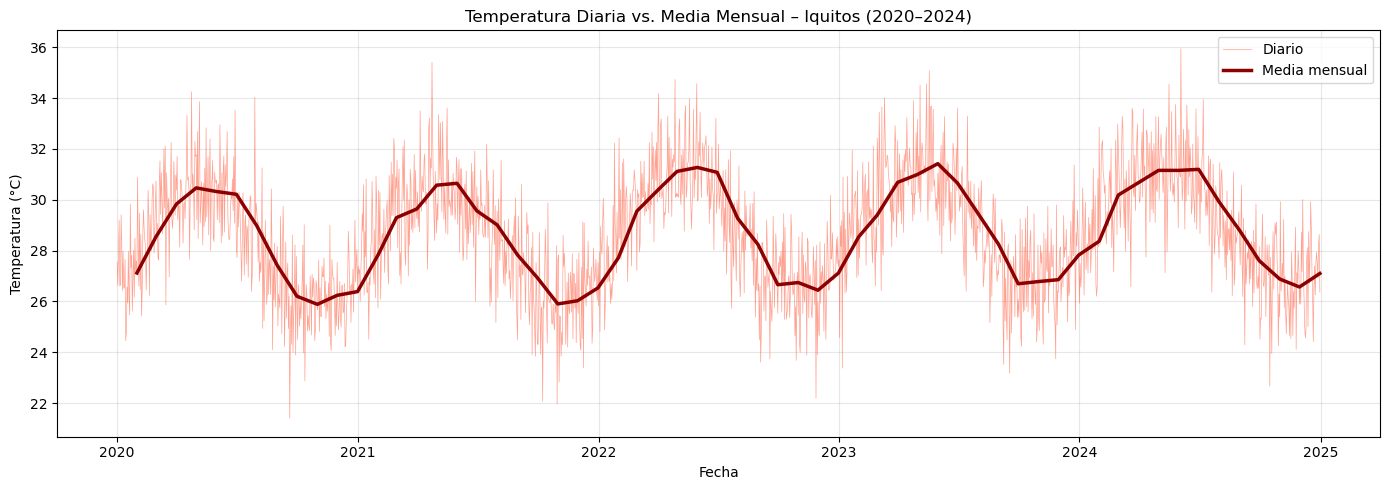

In [ ]:
# Comparar temperatura diaria vs. mensual
fig, ax = plt.subplots(figsize=(14, 5))

# Datos diarios (línea fina y transparente)
ax.plot(clima_ts.index, clima_ts['temperatura_c'],
        color='tomato', alpha=0.6, linewidth=0.5, label='Diario')

# Medias mensuales (línea gruesa)
ax.plot(mensual.index, mensual.values,
        color='darkred', linewidth=2.5, label='Media mensual')

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Temperatura Diaria vs. Media Mensual – Iquitos (2020–2024)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Estadísticas anuales

In [ ]:
# Calcular estadísticas anuales de temperatura
anual = clima_ts['temperatura_c'].resample('Y').agg(['mean', 'min', 'max'])
anual.index = anual.index.year
anual

C:\Users\cmillan\AppData\Local\Temp\ipykernel_67880\4047826268.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  anual = clima_ts['temperatura_c'].resample('Y').agg(['mean', 'min', 'max'])


,mean,min,max
fecha,,,
2020,28.129899,21.400557,34.249679
2021,28.305564,21.962746,35.407282
2022,28.789268,22.194494,34.732889
2023,28.962223,23.180014,35.076654
2024,29.128016,22.664911,35.940811


C:\Users\cmillan\AppData\Local\Temp\ipykernel_67880\3514567634.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  precip_anual = clima_ts['precipitacion_mm'].resample('Y').sum()


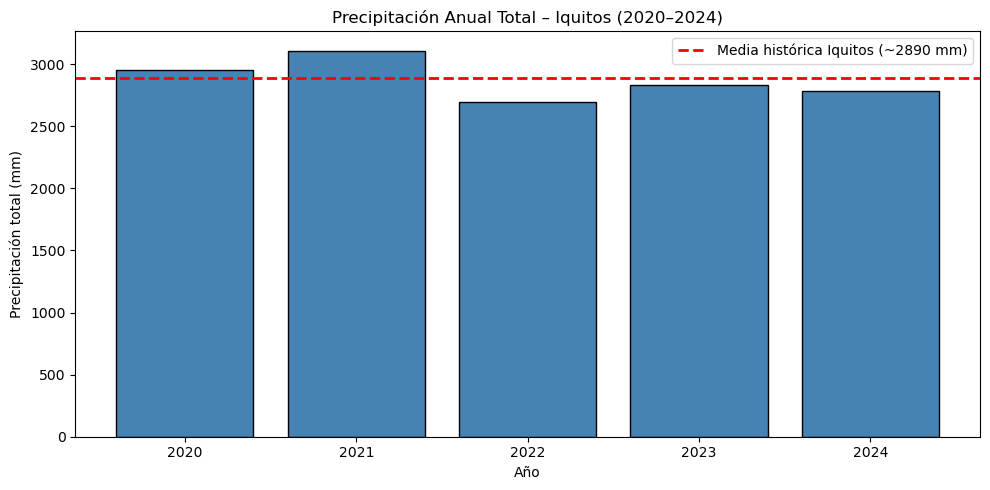

In [ ]:
# Precipitación total anual (mm)
precip_anual = clima_ts['precipitacion_mm'].resample('Y').sum()
precip_anual.index = precip_anual.index.year

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(precip_anual.index, precip_anual.values, color='steelblue', edgecolor='black')

# Línea de precipitación media histórica de Iquitos (~2890 mm)
ax.axhline(2890, color='red', linestyle='--', linewidth=2,
           label='Media histórica Iquitos (~2890 mm)')
ax.set_xlabel('Año')
ax.set_ylabel('Precipitación total (mm)')
ax.set_title('Precipitación Anual Total – Iquitos (2020–2024)')
ax.legend()
plt.tight_layout()
plt.show()

### 🔬 Ejercicio rápido 2 – Remuestreo

Usando `clima_ts`:

1. Calcula la **precipitación semanal acumulada** y muestra las primeras 8 semanas
2. Calcula la **temperatura máxima mensual** para cada mes de la serie
3. Crea un gráfico de barras de la precipitación media por mes (enero–diciembre promediado sobre todos los años). ¿Qué meses son los más lluviosos?

In [ ]:
# Tu código aquí

# precip_semanal = clima_ts['precipitacion_mm'].resample(???).sum()

# temp_max_mensual = clima_ts['temperatura_c'].resample(???).max()

# Para precipitación media por mes calendario:
# precip_por_mes = clima_ts['precipitacion_mm'].groupby(clima_ts.index.month).mean()
# fig, ax = plt.subplots(...)

---
## 5. Ventanas Deslizantes / Medias Móviles

Las **ventanas deslizantes** calculan estadísticas sobre una ventana de tamaño fijo que se desplaza. Son útiles para:
- Suavizar datos ruidosos
- Identificar tendencias
- Calcular estadísticas acumuladas

### 5.1 Media móvil simple

In [ ]:
# Calcular media móvil de 7 días (semanal)
clima_ts['temp_ma7']  = clima_ts['temperatura_c'].rolling(window=7).mean()

# Calcular media móvil de 30 días (mensual)
clima_ts['temp_ma30'] = clima_ts['temperatura_c'].rolling(window=30).mean()

clima_ts[['temperatura_c', 'temp_ma7', 'temp_ma30']].head(10)

,temperatura_c,temp_ma7,temp_ma30
fecha,,,
2020-01-01,27.548237,NaN,NaN
2020-01-02,26.634385,NaN,NaN
2020-01-03,27.852274,NaN,NaN
2020-01-04,29.204577,NaN,NaN
2020-01-05,26.608415,NaN,NaN
2020-01-06,26.648360,NaN,NaN
2020-01-07,29.408604,27.700693,NaN
2020-01-08,28.231441,27.798294,NaN
2020-01-09,26.416856,27.767218,NaN


In [ ]:
# Nota: Los primeros (ventana-1) valores son NaN
print(f"Valores NaN en MA7:  {clima_ts['temp_ma7'].isna().sum()}")
print(f"Valores NaN en MA30: {clima_ts['temp_ma30'].isna().sum()}")

Valores NaN en MA7:  6
Valores NaN en MA30: 29


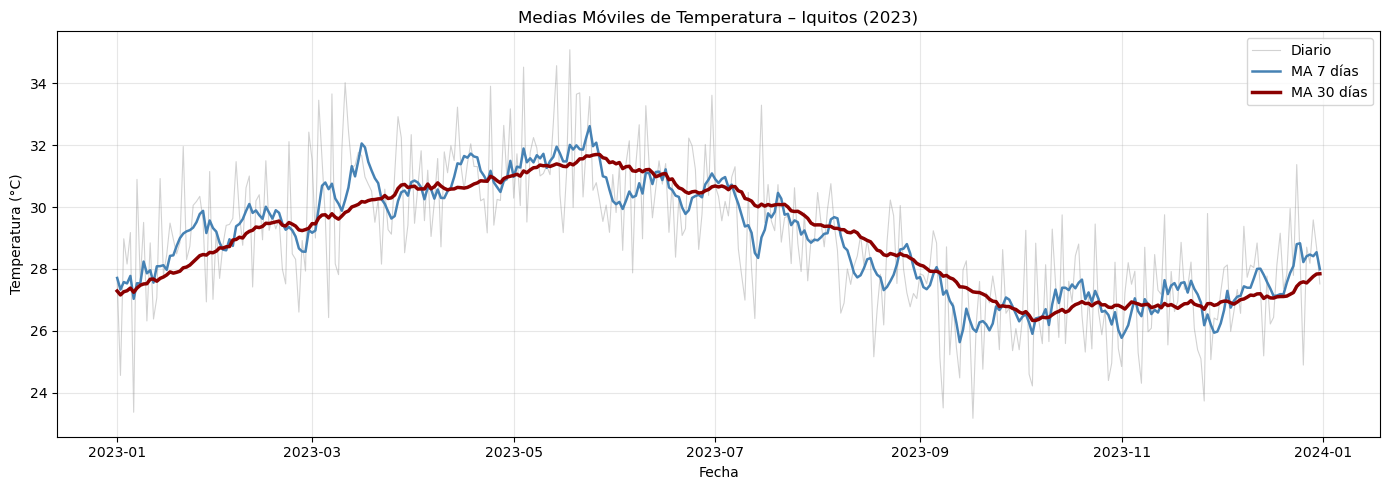

In [ ]:
# Visualizar el efecto de suavizado – año 2023
fig, ax = plt.subplots(figsize=(14, 5))

datos_2023 = clima_ts.loc['2023']

ax.plot(datos_2023.index, datos_2023['temperatura_c'],
        alpha=0.35, linewidth=0.8, label='Diario', color='gray')
ax.plot(datos_2023.index, datos_2023['temp_ma7'],
        linewidth=1.8, label='MA 7 días', color='steelblue')
ax.plot(datos_2023.index, datos_2023['temp_ma30'],
        linewidth=2.5, label='MA 30 días', color='darkred')

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Medias Móviles de Temperatura – Iquitos (2023)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Otras estadísticas deslizantes

In [ ]:
# Desviación estándar deslizante (variabilidad)
clima_ts['temp_std30'] = clima_ts['temperatura_c'].rolling(window=30).std()

# Mínimo y máximo deslizante de 30 días
clima_ts['temp_min30'] = clima_ts['temperatura_c'].rolling(window=30).min()
clima_ts['temp_max30'] = clima_ts['temperatura_c'].rolling(window=30).max()

# Suma deslizante de precipitación (14 días) – útil para alertas de inundación
clima_ts['precip_suma14'] = clima_ts['precipitacion_mm'].rolling(window=14).sum()

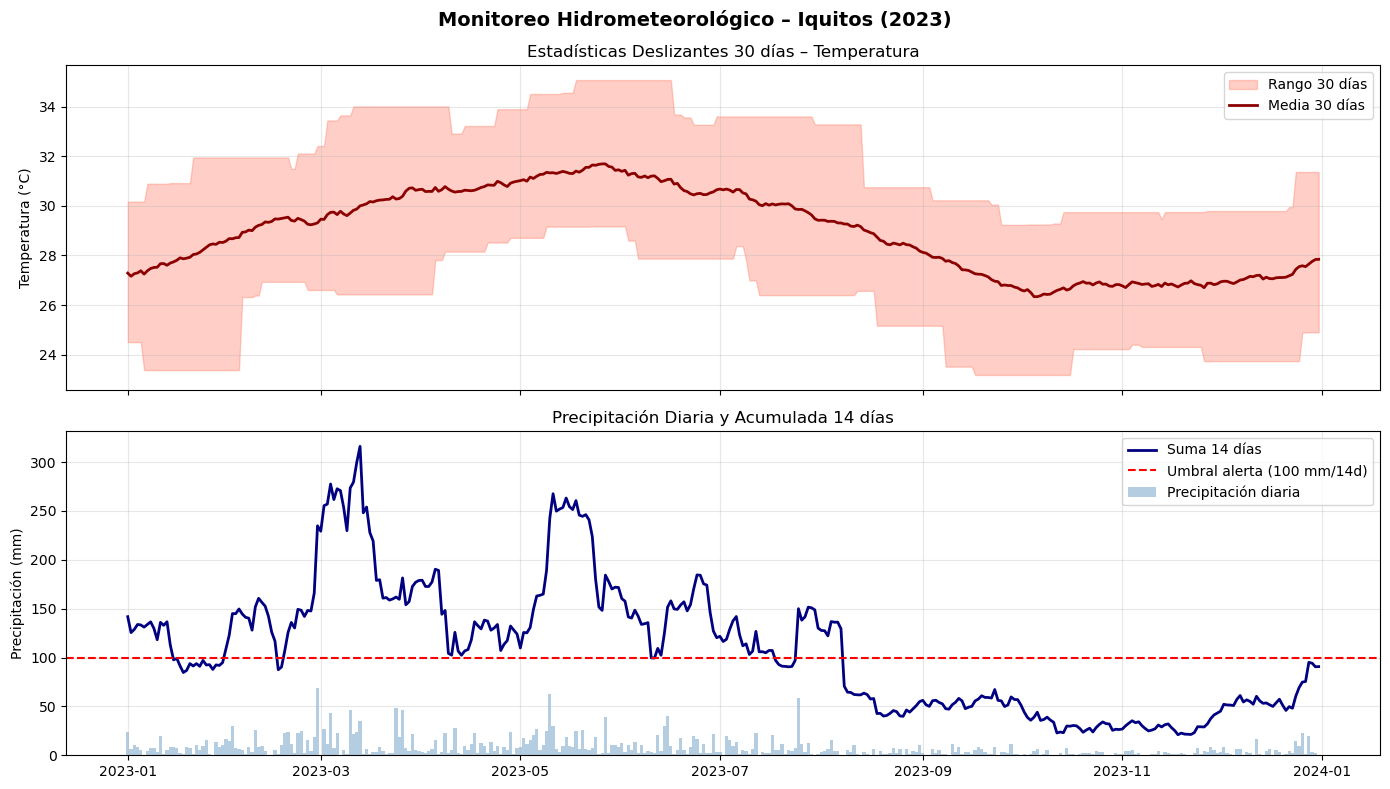

In [ ]:
# Gráfico de banda deslizante (mín–máx) con media – año 2023
fig, ejes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

datos_2023 = clima_ts.loc['2023']

# Temperatura con banda
ejes[0].fill_between(datos_2023.index,
                     datos_2023['temp_min30'],
                     datos_2023['temp_max30'],
                     alpha=0.3, color='tomato', label='Rango 30 días')
ejes[0].plot(datos_2023.index, datos_2023['temp_ma30'],
             linewidth=2, color='darkred', label='Media 30 días')
ejes[0].set_ylabel('Temperatura (°C)')
ejes[0].set_title('Estadísticas Deslizantes 30 días – Temperatura')
ejes[0].legend()
ejes[0].grid(True, alpha=0.3)

# Precipitación acumulada 14 días
ejes[1].bar(datos_2023.index, datos_2023['precipitacion_mm'],
            color='steelblue', alpha=0.4, label='Precipitación diaria', width=1)
ejes[1].plot(datos_2023.index, datos_2023['precip_suma14'],
             linewidth=2, color='navy', label='Suma 14 días')
ejes[1].axhline(100, color='red', linestyle='--', linewidth=1.5,
                label='Umbral alerta (100 mm/14d)')
ejes[1].set_ylabel('Precipitación (mm)')
ejes[1].set_title('Precipitación Diaria y Acumulada 14 días')
ejes[1].legend()
ejes[1].grid(True, alpha=0.3)

fig.suptitle('Monitoreo Hidrometeorológico – Iquitos (2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Ventana centrada vs. ventana rezagada

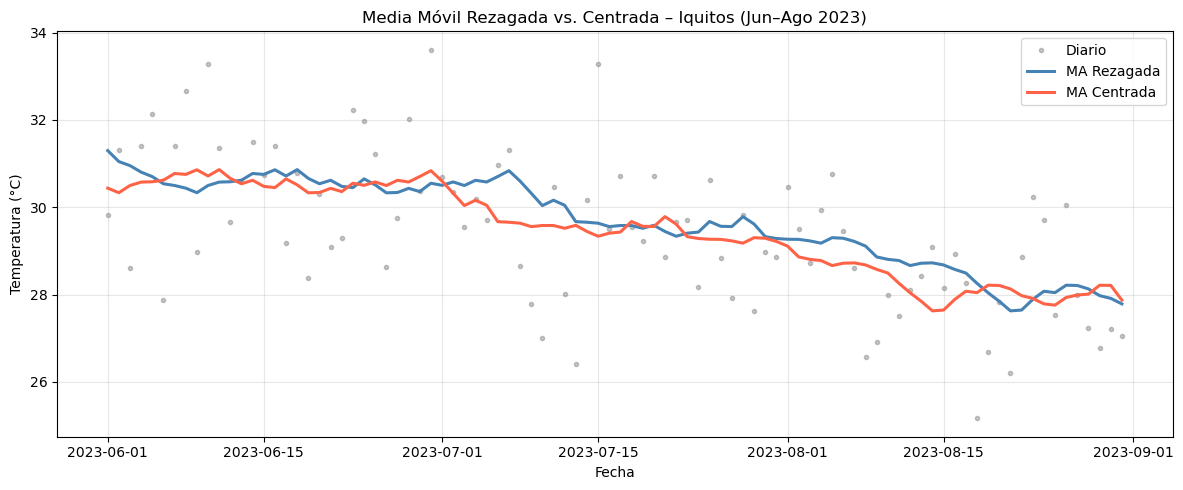

La MA centrada se alinea mejor con los picos y valles reales


In [ ]:
# Por defecto: ventana rezagada (usa valores pasados)
rezagada = clima_ts['temperatura_c'].rolling(window=15).mean()

# Ventana centrada (usa valores pasados y futuros)
centrada  = clima_ts['temperatura_c'].rolling(window=15, center=True).mean()

# Comparar
fig, ax = plt.subplots(figsize=(12, 5))

subconjunto = clima_ts.loc['2023-06':'2023-08']
ax.plot(subconjunto.index, subconjunto['temperatura_c'],
        'o', markersize=3, alpha=0.45, label='Diario', color='gray')
ax.plot(subconjunto.index, rezagada.loc['2023-06':'2023-08'],
        linewidth=2.2, label='MA Rezagada', color='steelblue')
ax.plot(subconjunto.index, centrada.loc['2023-06':'2023-08'],
        linewidth=2.2, label='MA Centrada', color='tomato')

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Media Móvil Rezagada vs. Centrada – Iquitos (Jun–Ago 2023)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("La MA centrada se alinea mejor con los picos y valles reales")

---
## 6. Descomposición de Series de Tiempo

La descomposición separa la serie en:
1. **Tendencia:** Movimiento a largo plazo
2. **Estacional:** Patrones que se repiten a intervalos fijos
3. **Residual:** Ruido aleatorio tras eliminar tendencia y estacionalidad

### 6.1 Aditiva vs. Multiplicativa

- **Aditiva:** Datos = Tendencia + Estacional + Residual (amplitud estacional constante)
- **Multiplicativa:** Datos = Tendencia × Estacional × Residual (amplitud crece con la tendencia)

In [ ]:
clima_ts

,temperatura_c,precipitacion_mm,anio,mes,dia,dia_del_anio,dia_semana,semana,trimestre,nombre_mes,temp_ma7,temp_ma30,temp_std30,temp_min30,temp_max30,precip_suma14
fecha,,,,,,,,,,,,,,,,
2020-01-01,27.548237,5.468587,2020,1,1,1,2,1,1,January,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,26.634385,0.062833,2020,1,2,2,3,1,1,January,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,27.852274,6.337221,2020,1,3,3,4,1,1,January,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-04,29.204577,15.571335,2020,1,4,4,5,1,1,January,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-05,26.608415,6.133032,2020,1,5,5,6,1,1,January,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,27.515074,1.106919,2024,12,27,362,4,52,4,December,26.812430,27.039135,1.461442,24.410588,30.005852,50.388813
2024-12-28,26.914486,25.260067,2024,12,28,363,5,52,4,December,27.170129,27.003098,1.450331,24.410588,30.005852,67.048235
2024-12-29,28.179990,3.451371,2024,12,29,364,6,52,4,December,27.396676,27.031427,1.465163,24.410588,30.005852,55.958045


In [ ]:
# Realizar descomposición
# Usar period=365 para estacionalidad anual en datos diarios
descomposicion = seasonal_decompose(
    clima_ts['temperatura_c'],
    model='additive',
    period=365
)

print("Componentes:")
print(f"  - Tendencia: {type(descomposicion.trend)}")
print(f"  - Estacional: {type(descomposicion.seasonal)}")
print(f"  - Residual: {type(descomposicion.resid)}")

Componentes:
  - Tendencia: <class 'pandas.core.series.Series'>
  - Estacional: <class 'pandas.core.series.Series'>
  - Residual: <class 'pandas.core.series.Series'>


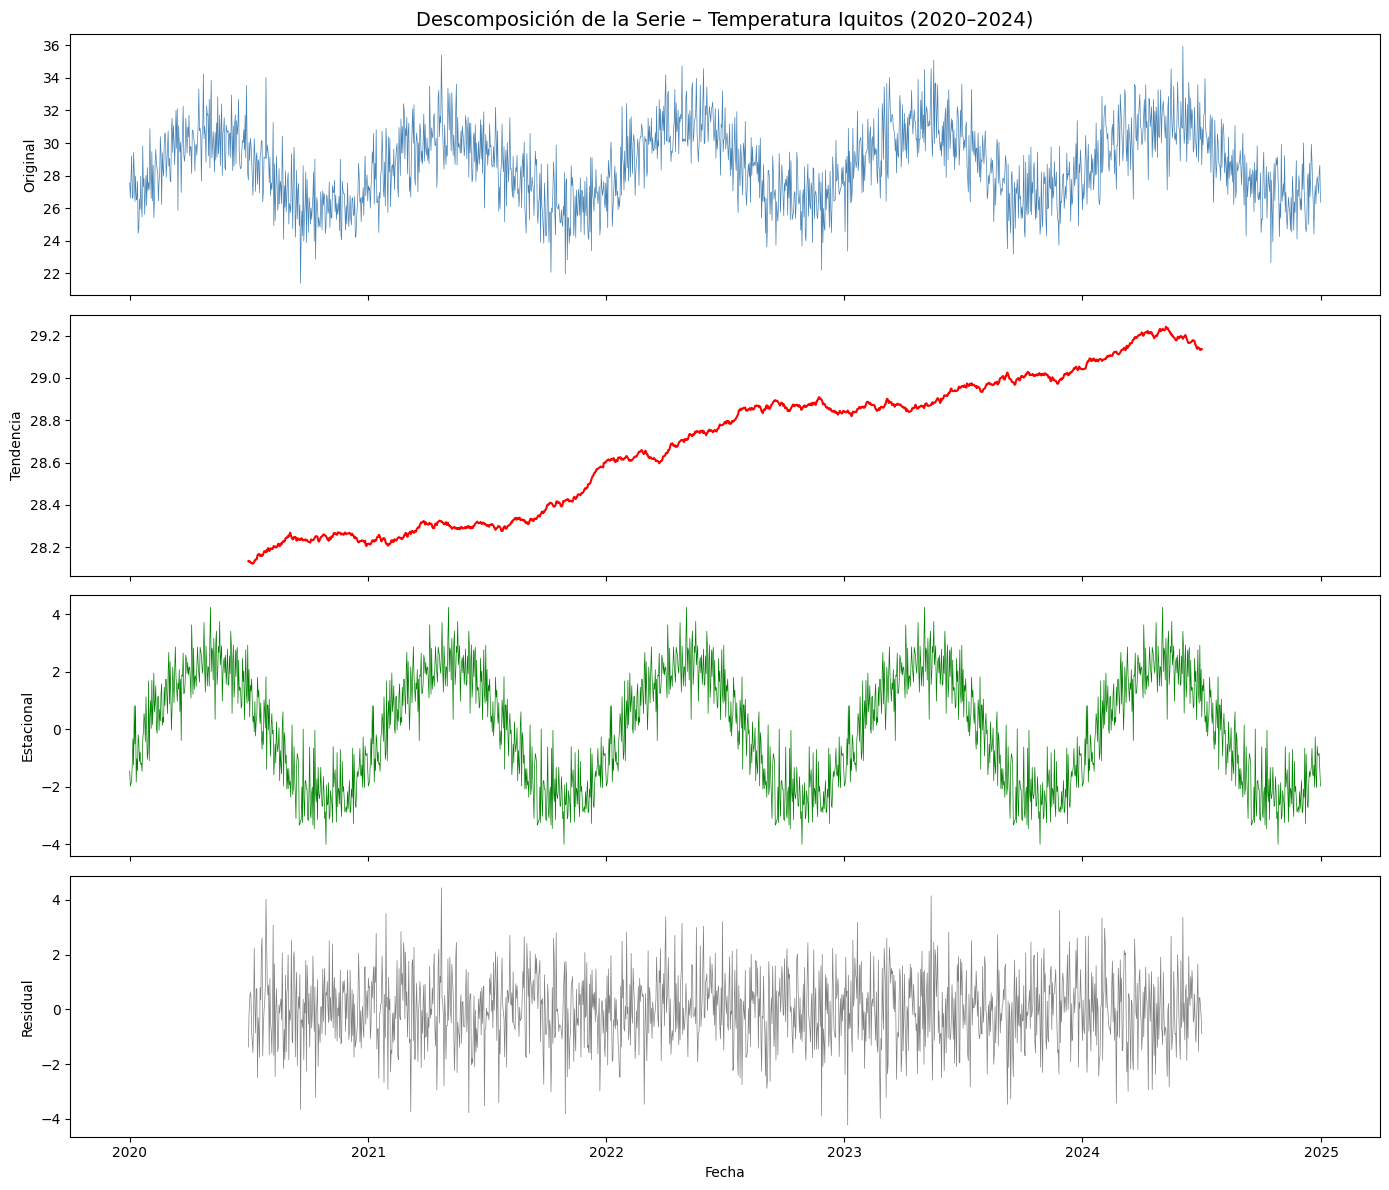

In [ ]:
# Visualizar descomposición
fig, ejes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

ejes[0].plot(clima_ts.index, clima_ts['temperatura_c'], linewidth=0.5, color='steelblue')
ejes[0].set_ylabel('Original')
ejes[0].set_title('Descomposición de la Serie – Temperatura Iquitos (2020–2024)',
                   fontsize=14)

ejes[1].plot(clima_ts.index, descomposicion.trend, color='red', linewidth=1.5)
ejes[1].set_ylabel('Tendencia')

ejes[2].plot(clima_ts.index, descomposicion.seasonal, color='green', linewidth=0.5)
ejes[2].set_ylabel('Estacional')

ejes[3].plot(clima_ts.index, descomposicion.resid, color='gray', linewidth=0.5)
ejes[3].set_ylabel('Residual')
ejes[3].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

### 6.2 Interpretar los componentes

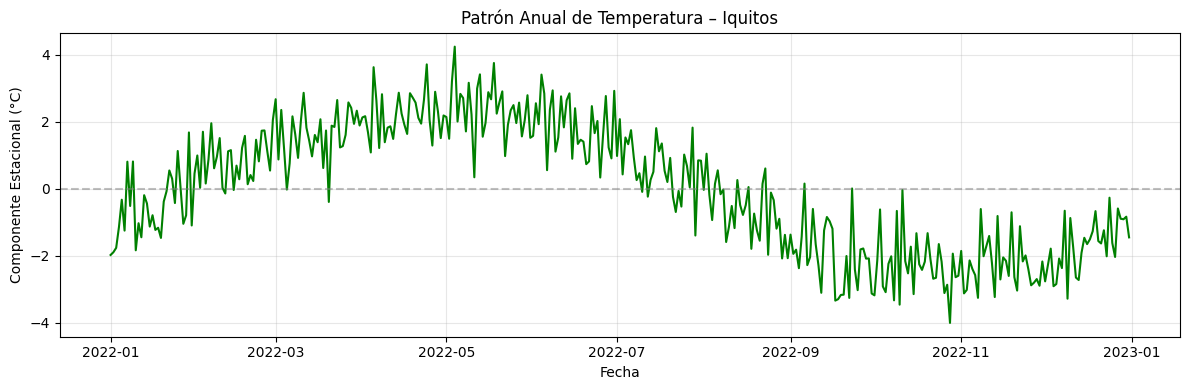

Amplitud estacional: 8.2°C
(Pequeña variación estacional esperada para clima ecuatorial amazónico)


In [ ]:
# Extraer el patrón estacional de un año
patron_estacional = descomposicion.seasonal.loc['2022']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(patron_estacional.index, patron_estacional.values, color='green', linewidth=1.5)
ax.set_xlabel('Fecha')
ax.set_ylabel('Componente Estacional (°C)')
ax.set_title('Patrón Anual de Temperatura – Iquitos')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Amplitud estacional: {patron_estacional.max() - patron_estacional.min():.1f}°C")
print("(Pequeña variación estacional esperada para clima ecuatorial amazónico)")

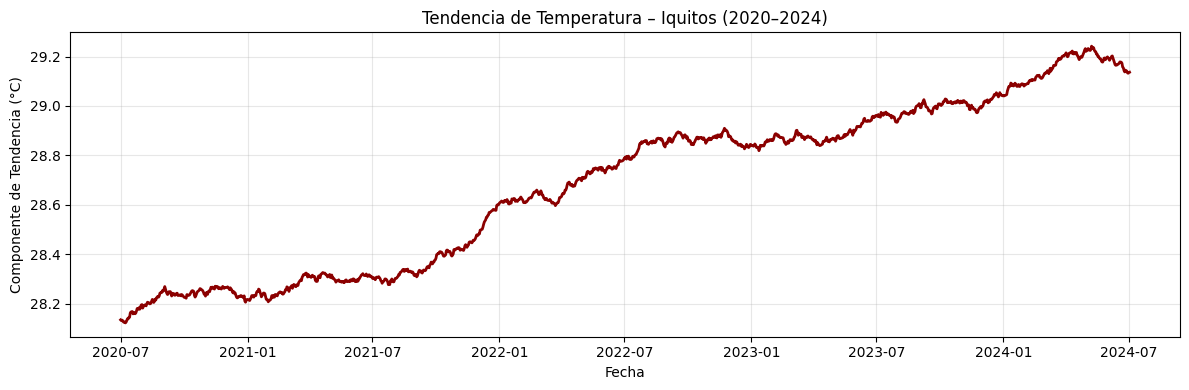

Cambio en la tendencia durante el período: +1.00°C


In [ ]:
# Analizar la tendencia – calentamiento a lo largo del período
tendencia = descomposicion.trend.dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tendencia.index, tendencia.values, color='darkred', linewidth=2)
ax.set_xlabel('Fecha')
ax.set_ylabel('Componente de Tendencia (°C)')
ax.set_title('Tendencia de Temperatura – Iquitos (2020–2024)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

cambio_tendencia = tendencia.iloc[-1] - tendencia.iloc[0]
print(f"Cambio en la tendencia durante el período: +{cambio_tendencia:.2f}°C")

### 6.3 Eliminar estacionalidad y tendencia

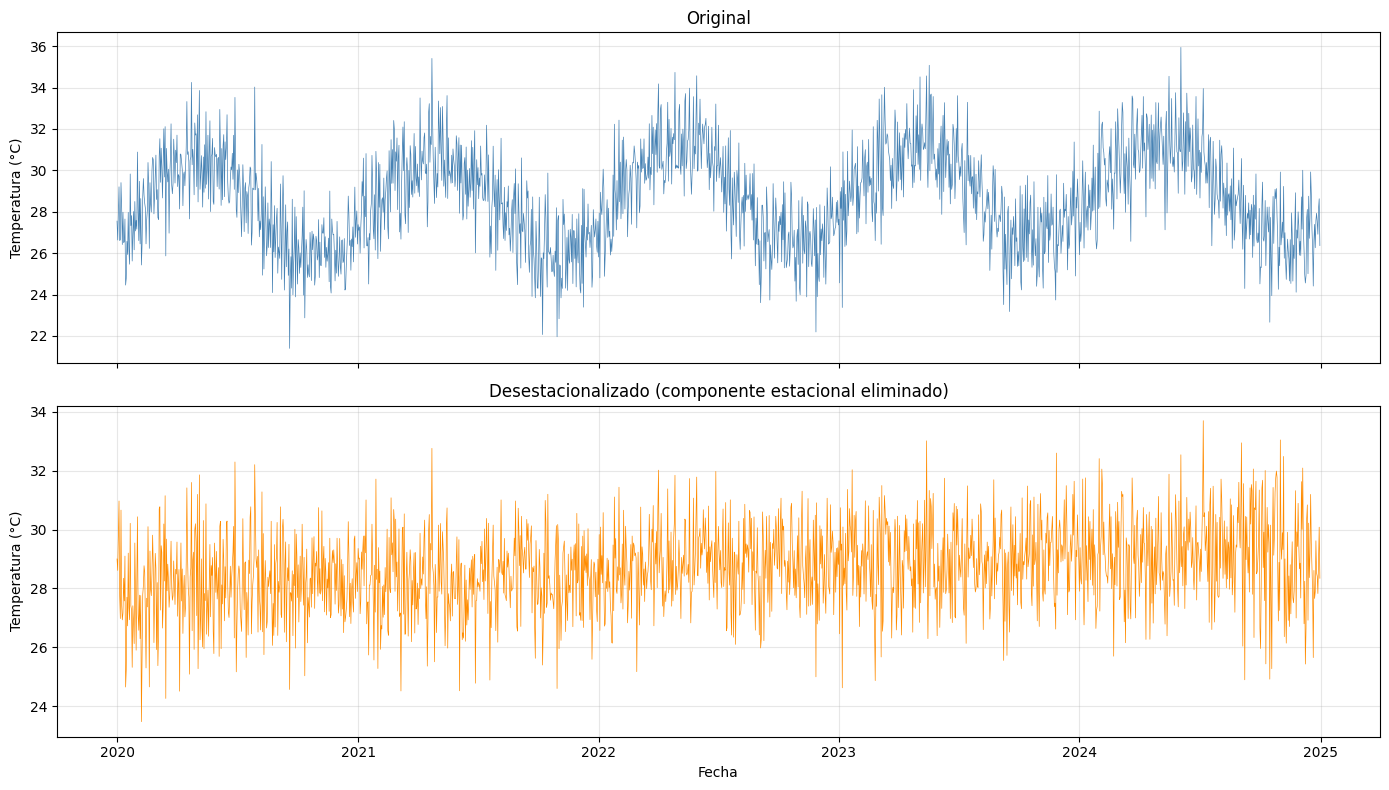

In [ ]:
# Eliminar estacionalidad para ver tendencia + residual
desestacionalizado = clima_ts['temperatura_c'] - descomposicion.seasonal

fig, ejes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ejes[0].plot(clima_ts.index, clima_ts['temperatura_c'], linewidth=0.5, color='steelblue')
ejes[0].set_ylabel('Temperatura (°C)')
ejes[0].set_title('Original')
ejes[0].grid(True, alpha=0.3)

ejes[1].plot(clima_ts.index, desestacionalizado, linewidth=0.5, color='darkorange')
ejes[1].set_ylabel('Temperatura (°C)')
ejes[1].set_title('Desestacionalizado (componente estacional eliminado)')
ejes[1].set_xlabel('Fecha')
ejes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🔬 Ejercicio rápido 3 – Descomposición

Realiza la descomposición de la **precipitación mensual** acumulada:

1. Remuestrea `clima_ts['precipitacion_mm']` a frecuencia mensual (suma)
2. Aplica `seasonal_decompose` con `period=12` (estacionalidad anual en datos mensuales)
3. Visualiza los 4 componentes
4. ¿Cuál es la amplitud del componente estacional? ¿Qué meses tienen más precipitación según el componente estacional?

In [ ]:
# Tu código aquí
# precip_mensual = clima_ts['precipitacion_mm'].resample('M').sum()
# descomp_precip = seasonal_decompose(precip_mensual, model='additive', period=12)
# fig, ejes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
# ...

---
## 7. Introducción al Modelado de Series de Tiempo

El modelado de series de tiempo permite comprender patrones y hacer pronósticos.

### 7.1 Autocorrelación

La **autocorrelación** mide cómo se correlaciona una serie con versiones rezagadas de sí misma. Revela:
- Cómo los valores pasados influyen en los futuros
- Patrones estacionales (picos en rezagos regulares)

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

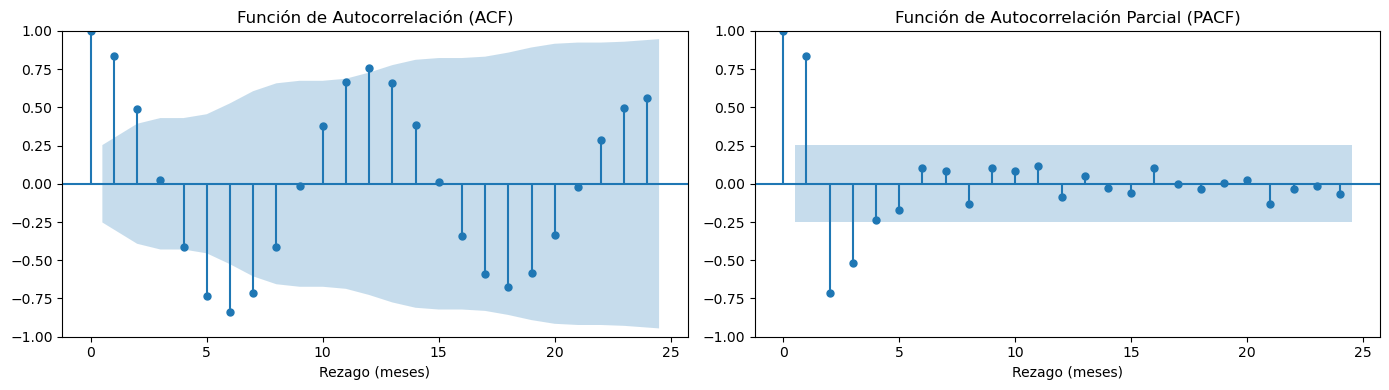

ACF: muestra correlación en rezago 12 (ciclo anual)
PACF: muestra la relación directa eliminando efectos intermedios


In [ ]:
# Graficar la función de autocorrelación (ACF) y autocorrelación parcial (PACF)
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))

# Usar datos mensuales para una visualización más clara
temp_mensual = clima_ts['temperatura_c'].resample('ME').mean()

plot_acf(temp_mensual.dropna(), lags=24, ax=ejes[0])
ejes[0].set_title('Función de Autocorrelación (ACF)')
ejes[0].set_xlabel('Rezago (meses)')

plot_pacf(temp_mensual.dropna(), lags=24, ax=ejes[1])
ejes[1].set_title('Función de Autocorrelación Parcial (PACF)')
ejes[1].set_xlabel('Rezago (meses)')

plt.tight_layout()
plt.show()

print("ACF: muestra correlación en rezago 12 (ciclo anual)")
print("PACF: muestra la relación directa eliminando efectos intermedios")

#### Comprender la ACF y PACF

**Función de Autocorrelación (ACF):**

La ACF mide la correlación entre la serie y sus valores rezagados. Para el rezago $k$:

$$\rho_k = \frac{\text{Cov}(y_t, y_{t-k})}{\text{Var}(y_t)} = \frac{\sum_{t=k+1}^{n}(y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{n}(y_t - \bar{y})^2}$$

Cómo interpretar la ACF:
- **Rezago 0** siempre es 1.0
- **Decaimiento lento** sugiere tendencia o no-estacionariedad
- **Picos en intervalos regulares** (ej. rezago 12 para datos mensuales) indican estacionalidad
- **Región sombreada** = intervalo de confianza al 95%

**Función de Autocorrelación Parcial (PACF):**

La PACF mide la correlación entre $y_t$ y $y_{t-k}$ **eliminando los efectos de los rezagos intermedios**.

| Patrón ACF | Patrón PACF | Modelo sugerido |
|------------|-------------|-----------------|
| Decaimiento exponencial | Corte abrupto tras rezago $p$ | AR($p$) |
| Corte abrupto tras rezago $q$ | Decaimiento exponencial | MA($q$) |
| Decaimiento exponencial | Decaimiento exponencial | ARMA($p$, $q$) |

### 7.2 Estacionariedad

Una serie de tiempo **estacionaria** tiene propiedades estadísticas constantes en el tiempo:
- Media constante
- Varianza constante
- Sin tendencia ni estacionalidad

La mayoría de los modelos de pronóstico requieren datos estacionarios. Usamos la **prueba de Dickey-Fuller Aumentada (ADF)** para verificarlo.

In [ ]:
def verificar_estacionariedad(serie, nombre):
    """Realizar prueba ADF e informar resultados."""
    resultado = adfuller(serie.dropna())
    print(f"\n{nombre}:")
    print(f"  Estadístico ADF: {resultado[0]:.4f}")
    print(f"  Valor p:         {resultado[1]:.4f}")
    if resultado[1] < 0.05:
        print("  → Estacionaria (se rechaza la hipótesis nula)")
    else:
        print("  → No estacionaria (no se rechaza la hipótesis nula)")

# Probar datos de temperatura originales
verificar_estacionariedad(temp_mensual, "Temperatura mensual original")

# Probar datos desestacionalizados
verificar_estacionariedad(desestacionalizado.resample('ME').mean(),
                          "Temperatura desestacionalizada")


Temperatura mensual original:
  Estadístico ADF: -0.8456
  Valor p:         0.8054
  → No estacionaria (no se rechaza la hipótesis nula)

Temperatura desestacionalizada:
  Estadístico ADF: -0.7914
  Valor p:         0.8216
  → No estacionaria (no se rechaza la hipótesis nula)


### 7.3 Diferenciación

La **diferenciación** elimina tendencias calculando el cambio entre observaciones consecutivas.

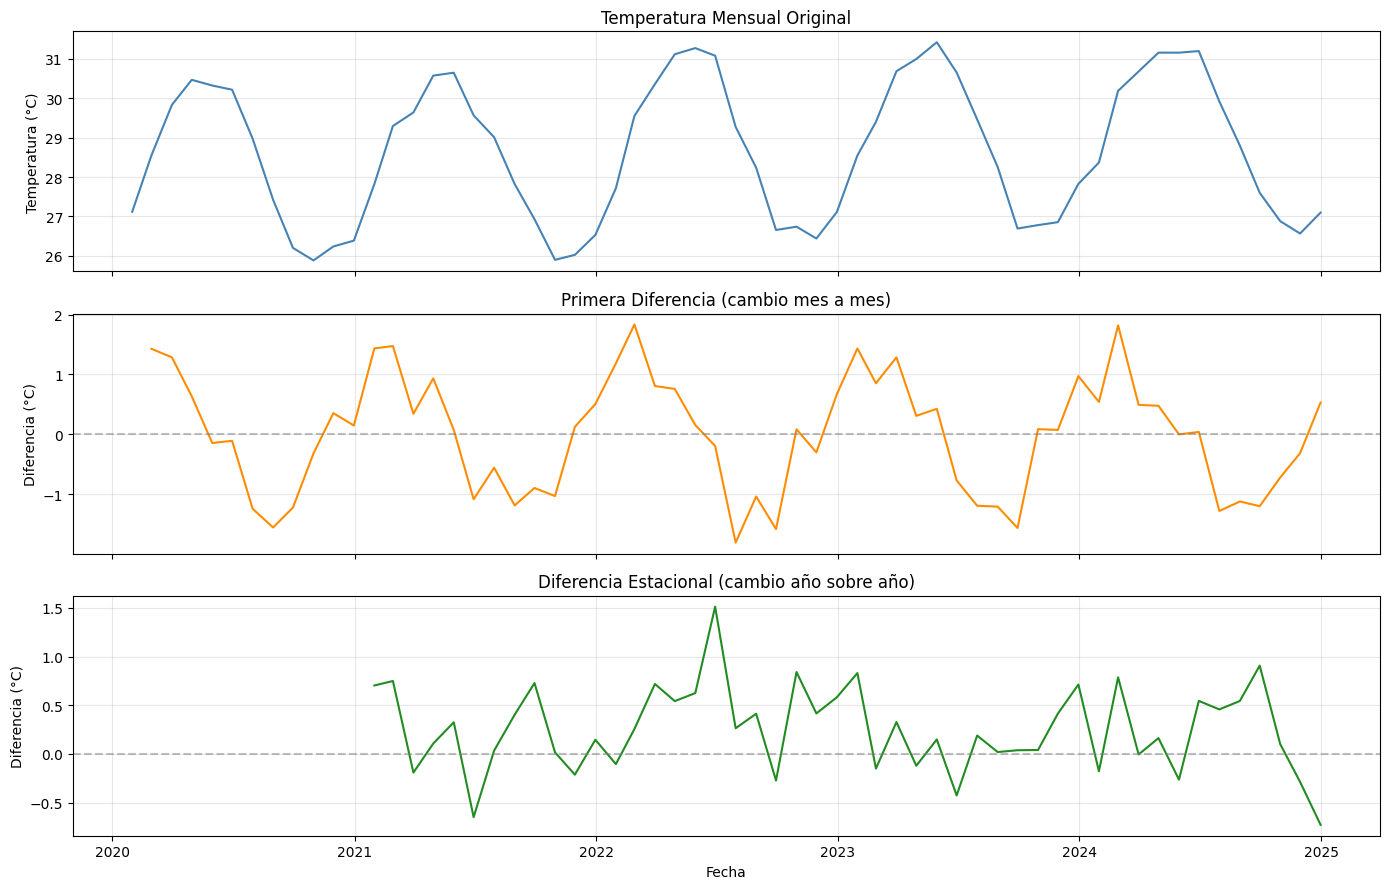

In [ ]:
# Primera diferencia: y(t) - y(t-1)
temp_diff = temp_mensual.diff().dropna()

# Diferencia estacional: y(t) - y(t-12) para datos mensuales
temp_diff_estacional = temp_mensual.diff(12).dropna()

fig, ejes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

ejes[0].plot(temp_mensual.index, temp_mensual.values, color='steelblue')
ejes[0].set_ylabel('Temperatura (°C)')
ejes[0].set_title('Temperatura Mensual Original')
ejes[0].grid(True, alpha=0.3)

ejes[1].plot(temp_diff.index, temp_diff.values, color='darkorange')
ejes[1].set_ylabel('Diferencia (°C)')
ejes[1].set_title('Primera Diferencia (cambio mes a mes)')
ejes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ejes[1].grid(True, alpha=0.3)

ejes[2].plot(temp_diff_estacional.index, temp_diff_estacional.values, color='forestgreen')
ejes[2].set_ylabel('Diferencia (°C)')
ejes[2].set_title('Diferencia Estacional (cambio año sobre año)')
ejes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ejes[2].set_xlabel('Fecha')
ejes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Verificar si la diferenciación logró la estacionariedad
verificar_estacionariedad(temp_diff, "Primera diferencia")
verificar_estacionariedad(temp_diff_estacional, "Diferencia estacional (rezago=12)")


Primera diferencia:
  Estadístico ADF: -5.1477
  Valor p:         0.0000
  → Estacionaria (se rechaza la hipótesis nula)

Diferencia estacional (rezago=12):
  Estadístico ADF: -1.9069
  Valor p:         0.3288
  → No estacionaria (no se rechaza la hipótesis nula)


### 7.4 Métodos simples de pronóstico

Antes de usar modelos complejos, prueba líneas de base simples:

| Método | Descripción |
|--------|-------------|
| Naive (Ingenuo) | Pronóstico = último valor observado |
| Naive Estacional | Pronóstico = valor del mismo período del año anterior |
| Media Móvil | Pronóstico = promedio de las últimas n observaciones |

In [ ]:
# Dividir datos en entrenamiento y prueba
entrenamiento = temp_mensual[:'2023']
prueba        = temp_mensual['2024']

print(f"Entrenamiento: {entrenamiento.index[0].date()} a {entrenamiento.index[-1].date()} ({len(entrenamiento)} meses)")
print(f"Prueba:        {prueba.index[0].date()} a {prueba.index[-1].date()} ({len(prueba)} meses)")

Entrenamiento: 2020-01-31 a 2023-12-31 (48 meses)
Prueba:        2024-01-31 a 2024-12-31 (12 meses)


In [ ]:
# Generar pronósticos con métodos simples

# 1. Naive: último valor repetido
pronostico_Naive = pd.Series([entrenamiento.iloc[-1]] * len(prueba), index=prueba.index)

# 2. Naive Estacional: mismo mes del año anterior (2023 → 2024)
pronostico_est = entrenamiento.loc['2023'].values
pronostico_est = pd.Series(pronostico_est, index=prueba.index)

# 3. Media Móvil: promedio de los últimos 12 meses
valor_ma = entrenamiento.iloc[-12:].mean()
pronostico_ma = pd.Series([valor_ma] * len(prueba), index=prueba.index)

In [ ]:
# Calcular precisión del pronóstico (RMSE)
def rmse(real, predicho):
    return np.sqrt(np.mean((real - predicho) ** 2))

print("Precisión del Pronóstico (RMSE – °C):")
print(f"  Naive:           {rmse(prueba, pronostico_Naive):.2f} °C")
print(f"  Naive Estacional:{rmse(prueba, pronostico_est):.2f} °C")
print(f"  Media Móvil:       {rmse(prueba, pronostico_ma):.2f} °C")

Precisión del Pronóstico (RMSE – °C):
  Naive:           2.16 °C
  Naive Estacional:0.50 °C
  Media Móvil:       1.73 °C


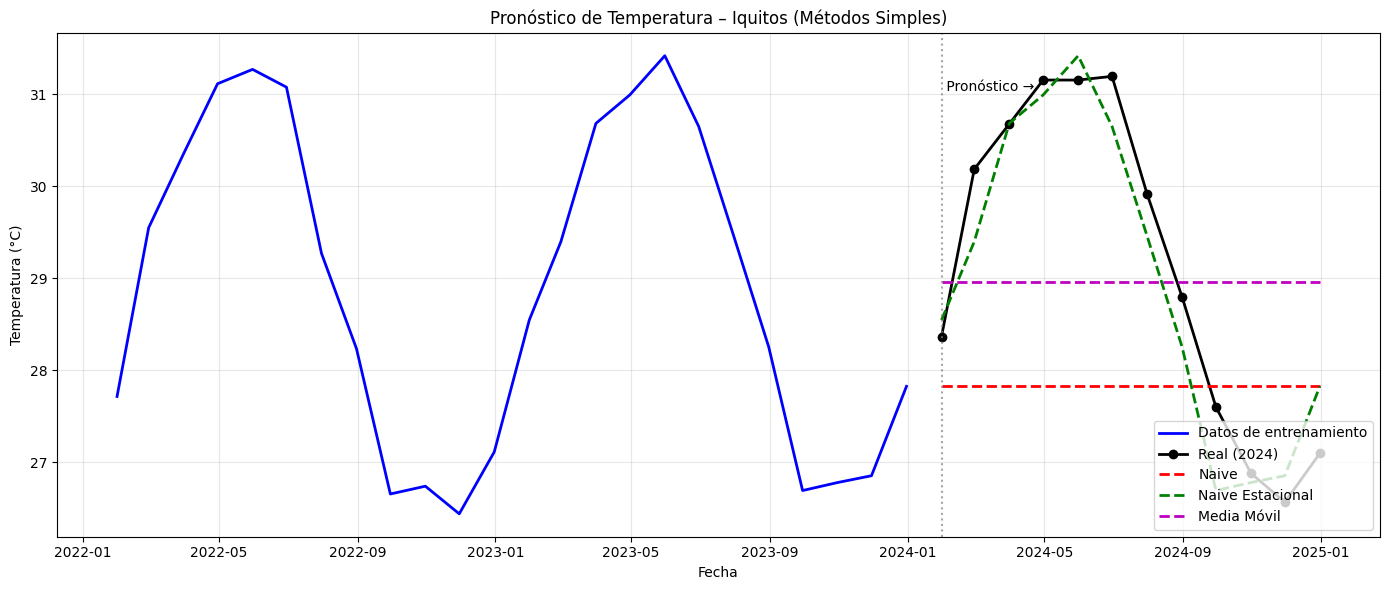


Naive Estacional capta mejor el patrón anual en datos estacionales


In [ ]:
# Visualizar pronósticos
fig, ax = plt.subplots(figsize=(14, 6))

# Datos de entrenamiento (últimos 2 años)
ax.plot(entrenamiento['2022':].index, entrenamiento['2022':].values,
        'b-', linewidth=2, label='Datos de entrenamiento')

# Datos reales de prueba
ax.plot(prueba.index, prueba.values,
        'ko-', linewidth=2, markersize=6, label='Real (2024)')

# Pronósticos
ax.plot(prueba.index, pronostico_Naive.values,
        'r--', linewidth=2, label='Naive')
ax.plot(prueba.index, pronostico_est.values,
        'g--', linewidth=2, label='Naive Estacional')
ax.plot(prueba.index, pronostico_ma.values,
        'm--', linewidth=2, label='Media Móvil')

ax.axvline(x=prueba.index[0], color='gray', linestyle=':', alpha=0.7)
ax.text(prueba.index[0], ax.get_ylim()[1] * 0.98, ' Pronóstico →', fontsize=10)

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Pronóstico de Temperatura – Iquitos (Métodos Simples)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNaive Estacional capta mejor el patrón anual en datos estacionales")

### 7.5 Suavizado Exponencial (Introducción breve)

El **suavizado exponencial** da más peso a las observaciones recientes. El método **Holt-Winters** maneja tanto tendencia como estacionalidad.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Ajustar modelo de Holt-Winters con estacionalidad aditiva
modelo_hw = ExponentialSmoothing(
    entrenamiento,
    seasonal_periods=12,
    trend='add',
    seasonal='add'
).fit()

# Pronosticar
pronostico_hw = modelo_hw.forecast(len(prueba))

print(f"RMSE Holt-Winters: {rmse(prueba, pronostico_hw):.2f} °C")

RMSE Holt-Winters: 0.33 °C


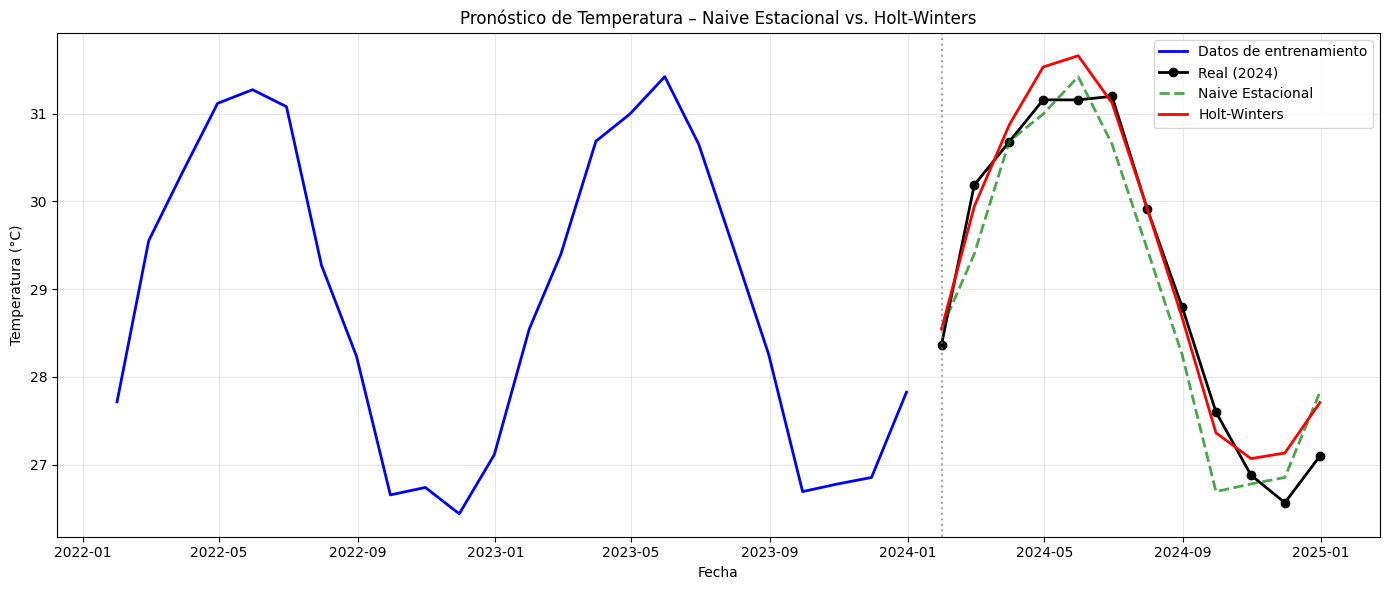

In [ ]:
# Comparar todos los métodos
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(entrenamiento['2022':].index, entrenamiento['2022':].values,
        'b-', linewidth=2, label='Datos de entrenamiento')
ax.plot(prueba.index, prueba.values,
        'ko-', linewidth=2, markersize=6, label='Real (2024)')
ax.plot(prueba.index, pronostico_est.values,
        'g--', linewidth=2, alpha=0.7, label='Naive Estacional')
ax.plot(prueba.index, pronostico_hw.values,
        'r-', linewidth=2, label='Holt-Winters')

ax.axvline(x=prueba.index[0], color='gray', linestyle=':', alpha=0.7)

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Pronóstico de Temperatura – Naive Estacional vs. Holt-Winters')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.6 Lectura adicional: Modelos ARMA y ARIMA (Leer después de clase)

Mientras que los métodos anteriores son poderosos y frecuentemente suficientes, series de tiempo más complejas pueden beneficiarse de modelos **ARIMA**.

#### Modelos Autorregresivos (AR)

Un modelo **AR($p$)** predice el valor actual como combinación lineal de los $p$ valores anteriores:

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

**Ejemplo: AR(1)**
$$y_t = c + \phi_1 y_{t-1} + \varepsilon_t$$

Si $\phi_1 = 0.8$, un valor alto ayer tiende a ir seguido de un valor alto hoy.

#### Modelos de Media Móvil (MA)

Un modelo **MA($q$)** predice el valor actual basándose en errores de pronóstico pasados:

$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

#### Modelos ARIMA

**ARIMA($p$, $d$, $q$)** extiende ARMA incluyendo diferenciación para manejar datos no estacionarios:
- $p$ = orden del componente AR
- $d$ = grado de diferenciación
- $q$ = orden del componente MA

#### SARIMA – ARIMA Estacional

Para datos con estacionalidad:

$$\text{SARIMA}(p, d, q) \times (P, D, Q)_m$$

Donde $m$ = período estacional (ej. 12 para datos mensuales con ciclo anual).

#### Implementación en Python (Referencia)

```python
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ajustar modelo ARIMA
modelo = ARIMA(datos, order=(p, d, q))
resultado = modelo.fit()
pronostico = resultado.forecast(steps=12)

# Ajustar modelo SARIMA
modelo = SARIMAX(datos, order=(p, d, q), seasonal_order=(P, D, Q, m))
resultado = modelo.fit()
pronostico = resultado.forecast(steps=12)

# Selección automática de modelo
# pip install pmdarima
from pmdarima import auto_arima
modelo = auto_arima(datos, seasonal=True, m=12)
```

#### Lecturas recomendadas

- **Hyndman & Athanasopoulos (2021)**: *Forecasting: Principles and Practice* (gratis en línea: https://otexts.com/fpp3/)
- **Box, Jenkins, Reinsel, & Ljung (2015)**: *Time Series Analysis: Forecasting and Control* (classic reference)
- **Documentación de statsmodels**: https://www.statsmodels.org/stable/tsa.html

---
## 8. Ejercicio integrador

Usando `clima_ts`:

1. Calcula la **precipitación total mensual** para cada mes
2. Encuentra qué mes (en toda la serie) tuvo la **mayor precipitación total** – ¿corresponde a la época de lluvias amazónica?
3. Calcula una **suma deslizante de 14 días** de precipitación (útil para detectar riesgo de inundación) y señala en el gráfico los períodos donde supera los 150 mm acumulados
4. Usando el **método Naive estacional**, pronostica la precipitación mensual del segundo semestre de 2024 (Jul–Dic) usando el mismo período de 2023 como referencia

In [ ]:
# Tu código aquí

# 1. Precipitación total mensual
# precip_mensual_total = clima_ts['precipitacion_mm'].resample('M').sum()

# 2. Mes con mayor precipitación
# mes_max = precip_mensual_total.idxmax()
# print(f"Mayor precipitación: {precip_mensual_total.max():.1f} mm en {mes_max.strftime('%B %Y')}")

# 3. Suma deslizante 14 días y alerta
# clima_ts['precip_14d'] = clima_ts['precipitacion_mm'].rolling(window=14).sum()
# fig, ax = plt.subplots(figsize=(14, 5))
# ...

# 4. Pronóstico Naive estacional
# prueba_precip = precip_mensual_total['2024-07':'2024-12']
# pronostico_precip = precip_mensual_total['2023-07':'2023-12'].values
# ...

---
## Resumen

| Tarea | Método |
|-------|--------|
| Convertir a datetime | `pd.to_datetime()` |
| Extraer componentes | `.dt.year`, `.dt.month`, `.dt.dayofyear` |
| Establecer índice datetime | `df.set_index('fecha')` |
| Seleccionar por fecha | `df.loc['2023-07']`, `df.loc['2023-06':'2023-08']` |
| Remuestrear frecuencia | `df.resample('M').mean()`, `df.resample('Y').sum()` |
| Media móvil | `df.rolling(window=7).mean()` |
| Descomposición | `seasonal_decompose(serie, period=365)` |
| Autocorrelación | `plot_acf()`, `plot_pacf()` |
| Prueba de estacionariedad | `adfuller()` |
| Diferenciación | `serie.diff()`, `serie.diff(12)` |
| Suavizado exponencial | `ExponentialSmoothing().fit().forecast()` |
| ARIMA | `ARIMA(datos, order=(p,d,q)).fit()` |
| SARIMA estacional | `SARIMAX(datos, order=(p,d,q), seasonal_order=(P,D,Q,m))` |

**Conceptos de modelado clave:**
- La **ACF** muestra la correlación total en cada rezago; la **PACF** muestra la directa eliminando efectos intermedios
- La estacionariedad es requisito para ARMA/ARIMA; usar la prueba ADF para verificar
- La diferenciación transforma datos no estacionarios en estacionarios
- Siempre comparar modelos complejos con líneas de base simples (Naive, Naive estacional)
- Los modelos **AR($p$)** usan valores pasados; los **MA($q$)** usan errores pasados
- **ARIMA($p$,$d$,$q$)** añade diferenciación para manejar tendencias
- **SARIMA** extiende ARIMA con componentes estacionales

---
## Soluciones

In [ ]:
# Solución Ejercicio rápido 1 – Indexado temporal
# 1. Temperatura media en 2022
datos_2022 = clima_ts.loc['2022']
print(f"Temperatura media 2022: {datos_2022['temperatura_c'].mean():.2f}°C")

# 2. Precipitación total en vaciante 2023
vaciante_2023 = clima_ts.loc['2023-06-01':'2023-09-30']
precip_vaciante = vaciante_2023['precipitacion_mm'].sum()
print(f"Precipitación total vaciante 2023 (Jun–Sep): {precip_vaciante:.1f} mm")

# 3. Días con precipitación > 20 mm
dias_lluviosos = len(clima_ts[clima_ts['precipitacion_mm'] > 20])
print(f"Días con precipitación > 20 mm: {dias_lluviosos}")

In [ ]:
# Solución Ejercicio rápido 2 – Remuestreo
# 1. Precipitación semanal acumulada
precip_semanal = clima_ts['precipitacion_mm'].resample('W').sum()
print("Precipitación semanal acumulada (primeras 8 semanas):")
print(precip_semanal.head(8))

# 2. Temperatura máxima mensual
temp_max_mensual = clima_ts['temperatura_c'].resample('M').max()
print("\nTemperatura máxima mensual (primeros 6 meses):")
print(temp_max_mensual.head(6))

# 3. Precipitación media por mes calendario
precip_por_mes = clima_ts['precipitacion_mm'].groupby(clima_ts.index.month).mean()
nombres_meses  = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 13), precip_por_mes.values, color='steelblue', edgecolor='black')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(nombres_meses)
ax.set_xlabel('Mes')
ax.set_ylabel('Precipitación media diaria (mm)')
ax.set_title('Precipitación Media por Mes – Iquitos (patrón estacional)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMeses más lluviosos: {nombres_meses[precip_por_mes.idxmax()-1]} "
      f"({precip_por_mes.max():.1f} mm/día media)")

In [ ]:
# Solución Ejercicio rápido 3 – Descomposición de precipitación mensual
precip_mensual_ds = clima_ts['precipitacion_mm'].resample('M').sum()
descomp_precip = seasonal_decompose(precip_mensual_ds, model='additive', period=12)

fig, ejes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

ejes[0].plot(precip_mensual_ds.index, precip_mensual_ds.values, color='steelblue')
ejes[0].set_ylabel('Precipitación (mm)')
ejes[0].set_title('Descomposición Precipitación Mensual – Iquitos', fontsize=13)

ejes[1].plot(precip_mensual_ds.index, descomp_precip.trend, color='red', linewidth=1.5)
ejes[1].set_ylabel('Tendencia')

ejes[2].plot(precip_mensual_ds.index, descomp_precip.seasonal, color='green')
ejes[2].set_ylabel('Estacional')

ejes[3].plot(precip_mensual_ds.index, descomp_precip.resid, color='gray')
ejes[3].set_ylabel('Residual')
ejes[3].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

# Amplitud estacional
patr = descomp_precip.seasonal.loc['2022']
print(f"Amplitud del componente estacional: {patr.max() - patr.min():.1f} mm")
mes_max_est = patr.idxmax().month
print(f"Mes con mayor componente estacional: {nombres_meses[mes_max_est-1]}")

In [ ]:
# Solución Ejercicio integrador
# 1. Precipitación total mensual
precip_mensual_total = clima_ts['precipitacion_mm'].resample('M').sum()

# 2. Mes con mayor precipitación
mes_max = precip_mensual_total.idxmax()
print(f"Mayor precipitación: {precip_mensual_total.max():.1f} mm en {mes_max.strftime('%B %Y')}")

# 3. Suma deslizante 14 días con alerta
clima_ts['precip_14d'] = clima_ts['precipitacion_mm'].rolling(window=14).sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(clima_ts.index, clima_ts['precip_14d'], color='steelblue', linewidth=0.8,
        label='Precipitación acumulada 14 días')
alerta_mask = clima_ts['precip_14d'] > 150
ax.fill_between(clima_ts.index, 0, clima_ts['precip_14d'],
                where=alerta_mask, color='red', alpha=0.4, label='Alerta (>150 mm/14d)')
ax.axhline(150, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fecha'); ax.set_ylabel('Precip. acumulada 14d (mm)')
ax.set_title('Precipitación Acumulada 14 Días – Alerta de Inundación – Iquitos')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Pronóstico Naive estacional (Jul–Dic 2024 usando Jul–Dic 2023)
prueba_precip    = precip_mensual_total['2024-07':'2024-12']
pronostico_precip = precip_mensual_total['2023-07':'2023-12'].values
pron_series = pd.Series(pronostico_precip, index=prueba_precip.index)

rmse_precip = np.sqrt(np.mean((prueba_precip - pron_series)**2))
print(f"\nRMSE pronóstico Naive estacional (precipitación): {rmse_precip:.1f} mm")